In [11]:
import torch
import torchvision

# import VGG19 model
model = torchvision.models.vgg19(pretrained=True)
model.eval()

# 
feature_maps = {}

# a hook is basically a listening device on a layer, it does not change the layer behavior
# but tracks the data of the layer, just to see what each layer takes in input and produces in output
# make hook is just a function to simplify the hook attachment to not write hook for each layer manually
def make_hook(name):
    def hook(module, input, output):
        # for each hook save output in the dict under specific name like 'layer 3', 'layer 4', etc. it does not matter
        feature_maps[name] = output
    return hook

# i chose random layers, in this case features count ReLU and pooling as layers too, so in total there are 36 instead of 19.
# i chose 4 layers to track, 2 early ones (3 and 4) and 2 late stage one (21 and 22)
model.features[3].register_forward_hook(make_hook('layer 3'))
model.features[4].register_forward_hook(make_hook('layer 4'))
model.features[21].register_forward_hook(make_hook('layer 21'))
model.features[22].register_forward_hook(make_hook('layer 22'))

# x is just a random image. 1 is 1 image, 3 is RGB (3 channels), 224x224 pixels
# 224x224 because vgg19 was trained on 224x224 images
x = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    model(x)

for name, tensor in feature_maps.items():
    print(name, tensor.shape)

layer 3 torch.Size([1, 64, 224, 224])
layer 4 torch.Size([1, 64, 112, 112])
layer 21 torch.Size([1, 512, 28, 28])
layer 22 torch.Size([1, 512, 28, 28])


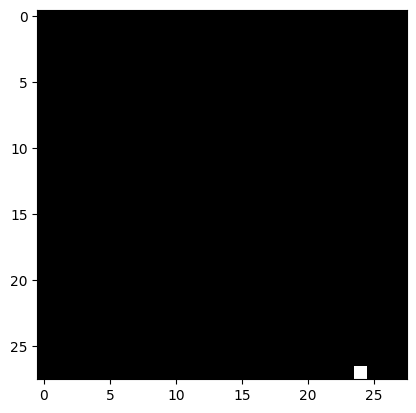

In [14]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

img = Image.open("augustus.jpeg")

# VGG19 standards
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# resize and normalize the image to ImageNet standards
transform = transforms.Compose([
    transforms.Resize((224, 224)), # vgg need 224x224 pixels
    transforms.ToTensor(), # ToTensor means bringing 0-255 scale to 0.0-1.0 scale
    transforms.Normalize(mean, std) # shift to ImageNet distribution
])

x = transform(img) # returns (3, 224, 224)
x = x.unsqueeze(0) # brings to (1 (batch), 3 (channels), 224, 224)

layer = feature_maps['layer 22'] # 21st layer
layer = layer.squeeze(0)

channel = layer[0].numpy() # make it a numpy array
plt.imshow(channel, cmap='gray')
plt.show()